# __Introduction to Sharpening/deblurring__

#Learning Objective

After completing this reading material, you will be able to:

* Explain the Importance of Image sharpening.

* Contrast Smoothing with sharpening

* Implement sharpening using Unsharp Mask.

Digital camera sensors and lenses often blur a picture to some degree, and this requires correction. In such case, Image sharpening can help.


## Image sharpening


* Image sharpening is an Image enhancement technique.
* Image sharpening highlights edges and fine details in an image.
* The objective of sharpening is to draw attention to the fine details of an image.


In the given figure Using Image sharpening technique, the blurry image is sharpened.


<image>
<center>

<!-- <img src="https://drive.google.com/uc?export=view&id=1xviNBzV400lV8yDuGW4IF-O_RUbk5FET"/> -->

<img src="https://i.postimg.cc/HnYfyWsp/image.png"/>

<Figcaption>Figure 1: Image Sharpening</Figcaption>

</center>
</image>




In `Figure 1,` The Image on the left-hand side is Blurred, and by Using sharpening, you sharpen the fine details of an image.

# __Blurring $\text{V}_\text{s}$ sharpening__

In the spatial domain, you can achieve blur by pixel smoothing in a neighborhood. Since smoothing/averaging is analogous to integration, it is reasonable to infer that spatial differentiation will bring about sharpening.

* Smoothing is also called low-pass filtering. Similarly, sharpening is also called highpass filtering.



 The differentiation of images enhances edges and de-emphasizes areas with slowly varying intensities.



##  __First and Second order derrivatives__

Our interest is in the behavior of this derivative on areas of constant intensity and intensity boosts at the start and end of discontinuities.


<image>
<center>

<!-- <img src="https://drive.google.com/uc?export=view&id=1k-bPjmFah4n1LL6wnSnxj3lHH3HngrEY"/> -->

<img src="https://i.postimg.cc/hP3HXBFB/image.png"/>
<Figcaption>Figure 2: Image Stripe area</Figcaption>
</center>
</image>

In the above figure,

* Intensity transition is a point where the value of intensity changes.
* A ramp is a continuous decrease in pixel intensity value.
* Isolated point is the alone point; it has neighbors far from it.
* In a Flat segment, the intensity is constant.
* The thin line is local maxima.
* A step is a sudden rise in pixel intensity.


__The fundamental properties of these derivatives on the area of interest are:__



## First order derivative

Properties of first order derrivative:

* Must be zero in area of constant intensity.
* Must be nonzero at onset of intensity step or ramp.
* Must be nonzero along intensity ramps.  $_{[1]}$


A basic definition of the first-order derivative of a one-dimensional function $f(x)$ is:

$\frac{\partial f}{\partial x} =  f(x+1) - f(x) $


* It’s just the difference between subsequent values and measures the rate of change of the function.

## Second order derivative

Properties of seond order derrivative:

* Must be zero in area of constant intensity.
* Must be non zero at the onset(start) and end of an intensity step or a ramp.
* Must be zero along intensity ramps. $_{[1]}$


We define a second-order derivative as the difference.

$\frac{\partial^2 f}{\partial x^2} =  f(x+1) + f(x-1) -2f(x)$

* You add previous value and next value and subtract twice of current value to get the second-order derivative of a function.

Let's see how they satisfy the given condition above:

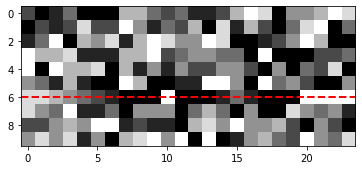

In [ ]:
#@title Image
import numpy as np
import matplotlib.pyplot as plt
a = [6,6,5,4,3,2,1,0,0,0,7,0,0,0,1,3,1,0,0,0,7,7,7,7]
np.random.seed(3)
X = np.random.randint(8, size=(10, 24))
X[6] = a
plt.axhline(y=6, color='r', linestyle='dashed', linewidth=2)
plt.imshow(X, cmap="gray")


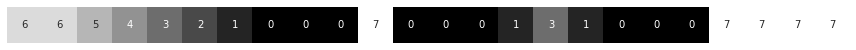

In [ ]:
# @title A section of a horizontal scan line from an image
import seaborn as sns
plt.figure(figsize=(12,0.8))
sns.heatmap(X[6].reshape(1,-1), cmap='gray', annot=True, cbar=False, )
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('stripe.png', dpi=500)
plt.show()

In [ ]:
#@title Calculate First and Second order derivative
print("Values of Image stripe: {} ".format(a))
first_order = []

for i in range(len(a)):
    if i == 0:
        continue
    elif i == len(a):
        continue
    else:
        first_order.append(a[i] - a[i-1])

print("First order derivative value are: {}".format(first_order))

second = []
for i in range(len(a)):
    if i == 0:
        continue
    elif i == len(a)-1:
        break
    else:
        second.append(a[i+1] + a[i-1] - 2* a[i])

print("Second order derivative value are: {} ".format(second))


Values of Image stripe: [6, 6, 5, 4, 3, 2, 1, 0, 0, 0, 7, 0, 0, 0, 1, 3, 1, 0, 0, 0, 7, 7, 7, 7] 
First order derivative value are: [0, -1, -1, -1, -1, -1, -1, 0, 0, 7, -7, 0, 0, 1, 2, -2, -1, 0, 0, 7, 0, 0, 0]
Second order derivative value are: [-1, 0, 0, 0, 0, 0, 1, 0, 7, -14, 7, 0, 1, 1, -4, 1, 1, 0, 7, -7, 0, 0] 


In [ ]:
#@title Plot on Graph
def plot_graph(order, x1,y1, x2, y2):
    plt.figure(figsize=(12,7))
    plt.plot(np.array(order),'o-')
    plt.xticks(range(0,len(order)+1))
    ax = plt.gca()
    ax.spines['left'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    plt.xticks(range(x1,y1))
    plt.yticks(range(x2,y2))
    plt.show()

Plot the value of Image Stripe on the graph.

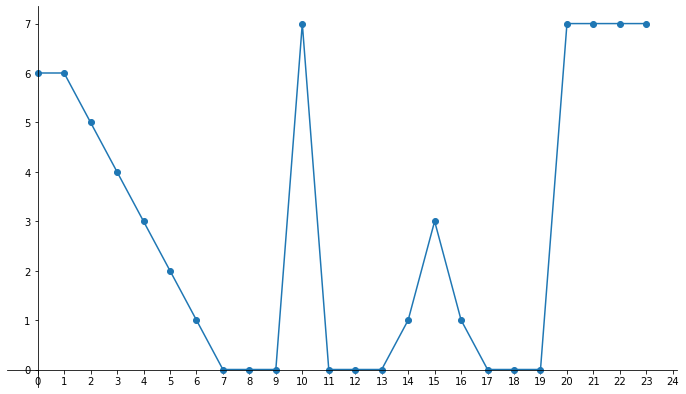

In [ ]:
plot_graph(a, x1 = 0, y1= len(a) +1 ,x2 = 0, y2 = max(a) +1)

Plot the value of the calculated value of the first-order derivative on the graph.

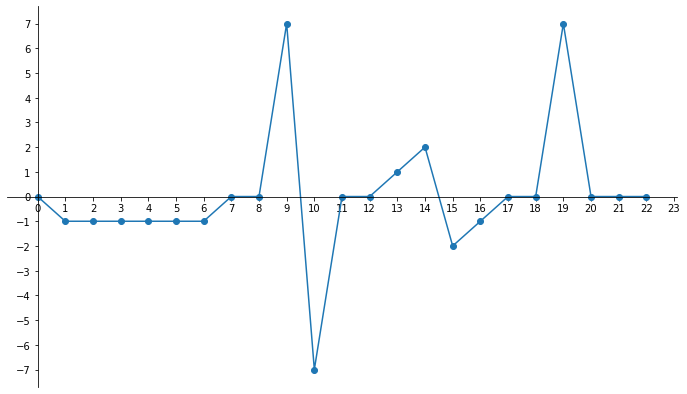

In [ ]:
plot_graph(first_order, x1 = 0, y1= len(first_order)+1 ,x2 = min(first_order), y2 = max(first_order) +1)

First order derrivative is the difference between subsequent values and measures the rate of change of the function.

For example:

$f(x) = 6$ at index $0$  and

$f(x+1) = 6$ at index $1$


* Then first order derivative is $6 - 6 =0$


Similarly,
* $f(x) = 6$ at index 1
and
$f(x+1) = 5$ at index 2,
Then first order derivative is $5 - 6 = -1$


__Plot the value of the calculated value of the second-order derivative on the graph.__

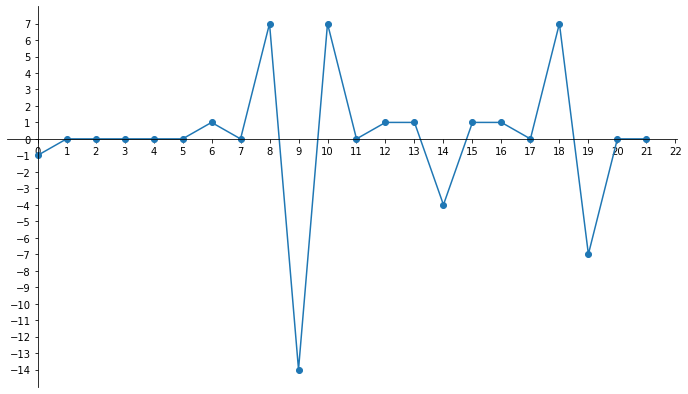

In [ ]:
plot_graph(second, x1 = 0, y1= len(second)+1 ,x2 = min(second), y2 = max(second)+1)

You add previous value and next value and subtract twice of current value to get the second-order derivative of a function.

For example:
* $f(x) = 6$ at index $0$
Then you cannot apply this operation.

* When $f(x) = 6$ at index $1$
    *  $f(x+1) = 5$ ,
    *  $f(x-1) = 6 $ and
    * $2 *f(x) = 12$

The second order derivative is : $6 + 5 - 12 = -1$


In X-axis, take a look at `7,8,9,10.` The line crosses zero. This crossing of a line is called zero crossings; it is useful for locating edges.

If you compare the response between first and second-order derivatives you will find:

1. The first-order derivative produces thick edges in an image.
2. Second-order derivatives respond strongly on the fine details like thin lines
and isolated points
3. The first-order derivative reacts strongly on a gray level step
4. The second-order derivative reacts doubly at step changes in the gray level.

The second-order derivative responds strongly on the line than in step. It also reacts strongly
on point than to a line.

Therefore second-order derivative is the best option for image enhancement because of
their ability to enhance finer details. First order derivative is used in edge extraction.


# The Laplacian for Image sharpening (2D Second order derivatives)

The isotropic filter response is independent of the discontinuity direction in the image. In other words, isotropic filters are isotropic invariant, which means rotating an image and applying it to a filter gives the same results as using it to an image first and rotating the result. One of the simple isotropic filters is Laplacian.$_{[1]}$ It is a 2D second-order derivative of image sharpening.

Laplacian highlights sharp intensity transitions in an image and de-emphasizes regions with slow
varying intensities. It results in an image with grayish edge lines and other discontinuities, all superimposed on a dark, featureless background.  $_{[3]}$

The laplacian is defined as follows:

$$
\begin{equation}
    \nabla^2 f = [f(x+1,y) + f(x-1,y) + f(x,y+1) + f(x,y-1) - 4f(x,y)]
\end{equation}
$$

You can easily built filter based on this:



$M1=
\begin{bmatrix}
0 & 1 & 0\\
1 & -4 & 1\\
0 & 1 & 0
\end{bmatrix}
$

$M2 =
\begin{bmatrix}
0 & -1 & 0\\
-1 & 4 & -1\\
0 & -1 & 0
\end{bmatrix}
$

You can add direction in these filters.



Implementation
$$
 g(x, y)=
    f(x,y) + c[\nabla^2 f(x, y)]
$$

- c = 1  If center coefficient is Positive
- c = -1  If center coefficient is Negative

In [ ]:
!wget -q --no-check-certificate 'https://upload.wikimedia.org/wikipedia/commons/thumb/0/07/Polished_kukri.jpg/800px-Polished_kukri.jpg' -O inputs.png

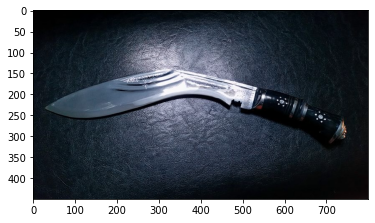

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('inputs.png')
plt.imshow(img,cmap='gray')

Apply $f1 ~and ~f2$ kernel.

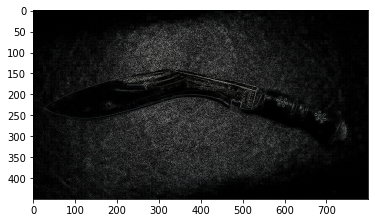

In [ ]:
kernel_sharpen_1 = np.array([[0,1,0], [1,-4,1], [0,1,0]])
# applying f1 kernels to the input image
output_1 = cv2.filter2D(img, -2, kernel_sharpen_1)
plt.imshow(output_1,cmap='gray')

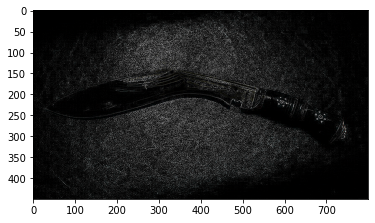

In [ ]:
kernel_sharpen_2 = np.array([[0,-1,0], [-1,4,-1], [0,-1,0]])
# applying f2 kernels to the input image
output_2= cv2.filter2D(img, -1, kernel_sharpen_2)
plt.imshow(output_2)

Add it to original Image.

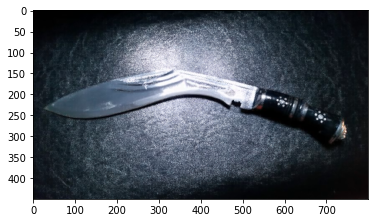

In [ ]:
lapsharp = cv2.add(img, output_1)
plt.imshow(lapsharp)

__Note:__

* Sharpening a blurry image will not magically create a clear Image. Sometime sharpening may create terrible results.


# Sharpening Image and Unsharp mask

Unsharp mask is used to sharpen the Image. It enhances the appearence of details.

__Steps:__

1. Blur the original image.

- Original Image: $f(x,y)$
- Blurred Image: $f_{smooth}(x,y)$
2. Subtract the blurred image from the original (the resulting difference is called the mask/edge Image.)
$$ g(x,y) = f(x,y) - f_{smooth}(x,y)$$

3. Add the mask to the original.

$$ f_{sharp}(x,y) = f(x,y) + g(x,y) *k $$

Here k>=0. when k =1, you do an unsharp mask. When k>1, it is called high boost filtering. If you use k<1, it reduces the contribution of the unsharp mask.

You can write above equation in one line as the weighted average of the original and the blurred image.

$ f_{sharp}(x,y) = (K+1) * f(x,y) - K * f_{smooth}(x,y) $

<image>
<center>

<!-- <img src="https://drive.google.com/uc?export=view&id=1sMG71WJj5g9K_phMhjfGBmMt40G8bRDl"/> -->

<img src="https://i.postimg.cc/Lsj7QgJ9/image.png"/>

<Figcaption>Figure 1: Unsharp Mask</Figcaption>

</center>
</image>




_An unsharp mask improves sharpness by increasing
acutance, although resolution remains the same_


Let's Implement thr given formula In a code.

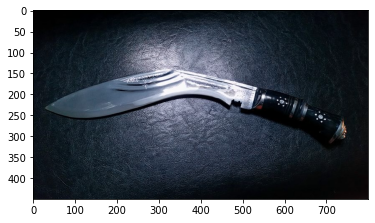

In [ ]:
plt.imshow(img)

In [ ]:
fsmooth = cv2.GaussianBlur(img, (7,7), 11,11)
gmask = cv2.subtract(img, fsmooth)

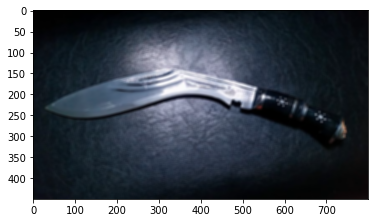

In [ ]:
plt.imshow(fsmooth, cmap='gray')


$ f_{sharp}(x,y) = f(x,y) + g(x,y) *k $

In [ ]:
# fsharp = img + gmask * 1
multgmask = np.multiply(gmask ,1)
fsharp = cv2.add(img, multgmask)

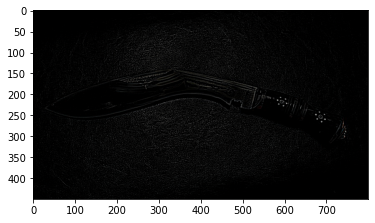

In [ ]:
plt.imshow(multgmask, cmap='gray')

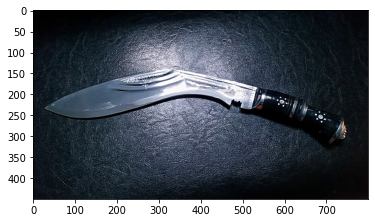

In [ ]:
plt.imshow(fsharp)

Let's Plot Images generated In all the above steps.

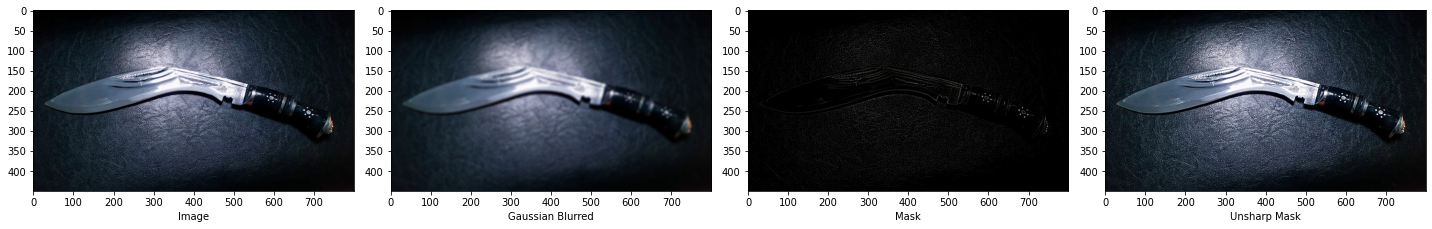

In [ ]:
#@title Plot Images
f, axes = plt.subplots(1, 4, figsize=(20,15))
axes[0].imshow(img, cmap='gray')
axes[1].imshow(fsmooth, cmap='gray')
axes[2].imshow(gmask, cmap='gray')
axes[3].imshow(fsharp, cmap='gray')
plt.setp(axes[0], xlabel='Image')
plt.setp(axes[1], xlabel='Gaussian Blurred')
plt.setp(axes[2], xlabel='Mask')
plt.setp(axes[3], xlabel='Unsharp Mask')
f.tight_layout()
plt.savefig('UnsharpMask.png')
plt.show()
plt.close()

__Note__

_The unsharp filter relies on a convolution kernel to perform spatial filtering._

# Unsharp masking with Python and OpenCV

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
img  = cv2.imread('inputs.png',1)
gauss = cv2.GaussianBlur(img, (7,7), 10,10)

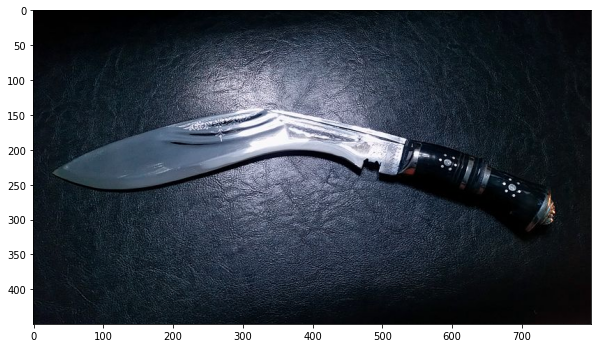

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(img, cmap='gray')

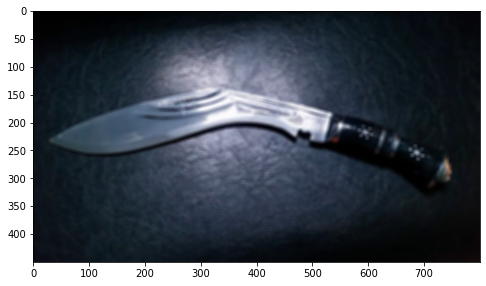

In [ ]:
plt.figure(figsize=(8,10))
plt.imshow(gauss, cmap='gray')

$ f_{sharp}(x,y) = (K+1) * f(x,y) - K * f_{smooth}(x,y) $

In [ ]:
# Apply Unsharp masking
# if K =1 then K+1 = 2
# fsmooth = gauss
#-1 is used to represent subtraction
unsharp_image = cv2.addWeighted(img, 2, gauss, -1, 0)

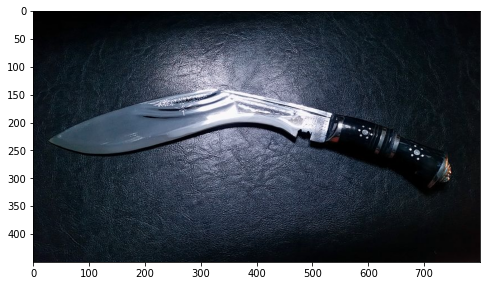

In [ ]:
plt.figure(figsize=(8,10))
plt.imshow(img,cmap='gray')

# Key Takeaways

- Image sharpening is an Image enhancement technique that highlights edges and fine details in an image.

- Smoothing is analogous to integration, it is reasonable to infer that spatial differentiation will bring about sharpening.

- The 1st-order derivative is nonzero along the entire ramp, while the 2nd-order derivative is nonzero only at the onset and end of the ramp.

-  One of the simple isotropic filters is Laplacian. It is a 2D second-order derivative of image sharpening.

- Subtracting an unsharp (smoothed) version $f_{smooth}(x,y)$ of an image from the original image $f(x,y)$ is called unsharp masking.

## References


[1] Gonzalez, R. C., & Woods, R. E. (2007). Image processing. Digital image processing, 2, 1.
* Chapter 3.6

[2] Mordvintsev, A., & Abid, K. (2016). OpenCV-Python Tutorials Documentation.

[3] Park, B., & Lu, R. (Eds.). (2015). Hyperspectral imaging technology in food and agriculture. New York, NY: Springer New York.
* Basics of Image analysis Page 31.